In [1]:
# -- 2 Pandas DataFrame --

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../../course_assignments/homework8/state_data.csv")

In [4]:
print(df.shape)

(52, 4)


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 52
Number of columns: 4


In [6]:
df.head()

,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


In [7]:
df.tail()

,state,latitude,longitude,name
47,VT,44.558803,-72.577841,Vermont
48,WA,47.751074,-120.740139,Washington
49,WI,43.784440,-88.787868,Wisconsin
50,WV,38.597626,-80.454903,West Virginia
51,WY,43.075968,-107.290284,Wyoming


the first column is the abbreviation of the state.
the second column is the latitude of the state.
the third column is the longitude of the state.
the fourth column is the full name of the state.

the first state is Alaska and the last state is Wyoming.
There are 52 entries in total.
It is more than 50 entries because the dataset also includes the District of Columbia and Puerto Rico.

In [8]:
median_latitude = df["latitude"].median()
median_longitude = df["longitude"].median()

print("Median latitude:", median_latitude)
print("Median longitude:", median_longitude)

Median latitude: 39.4355155
Median longitude: -89.093198


In [9]:
df["latitude_distance"] = abs(df["latitude"] - median_latitude)
df["longitude_distance"] = abs(df["longitude"] - median_longitude)

In [10]:
print(df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

(52, 6)
Number of rows: 52
Number of columns: 6


In [11]:
closest_latitude = df.loc[df["latitude_distance"].idxmin()]
farthest_latitude = df.loc[df["latitude_distance"].idxmax()]
closest_longitude = df.loc[df["longitude_distance"].idxmin()]
farthest_longitude = df.loc[df["longitude_distance"].idxmax()]

print(f'state closest to median latitude: {closest_latitude["name"]} by {closest_latitude["latitude_distance"]:.2f}')
print(f'state farthest to median latitude: {farthest_latitude["name"]} by {farthest_latitude["latitude_distance"]:.2f}')
print(f'state closest to median longitude: {closest_longitude["name"]} by {closest_longitude["longitude_distance"]:.2f}')
print(f'state farthest to median longitude: {farthest_longitude["name"]} by {farthest_longitude["longitude_distance"]:.2f}')

state closest to median latitude: Colorado by 0.11
state farthest to median latitude: Alaska by 24.15
state closest to median longitude: Illinois by 0.31
state farthest to median longitude: Hawaii by 66.57


In [12]:
df.describe()

,latitude,longitude,latitude_distance,longitude_distance
count,52.000000,52.000000,52.000000,52.000000
mean,39.153437,-92.824719,4.815714,14.535330
std,6.967697,19.431647,4.998411,13.280351
min,18.220833,-155.665857,0.114536,0.305330
25%,35.438381,-102.009600,1.564952,6.037732
50%,39.435516,-89.093198,3.890968,11.903743
75%,43.220246,-78.291302,6.133912,17.832342
max,63.588753,-66.590149,24.153237,66.572659


For this question, I used the pandas function describe().
I found it on the Pandas documentation website in the section about summarizing data.
The function summarizes numerical data in a DataFrame. It shows various statistics like count, mean, standard deviation, min, max, and quartiles. 
It's helpful if I want a quick summary of the data.

In [13]:
# -- 3 Seaborn --

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
crashes = sns.load_dataset("car_crashes")
crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [16]:
crashes = crashes.dropna(axis=1)
crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [17]:
crashes.shape
print("Number of rows:", crashes.shape[0])
print("Number of columns:", crashes.shape[1])

Number of rows: 51
Number of columns: 8


In [18]:
crashes.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


In [19]:
crashes.tail()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
46,12.7,2.413,3.429,11.049,11.176,768.95,153.72,VA
47,10.6,4.452,3.498,8.692,9.116,890.03,111.62,WA
48,23.8,8.092,6.664,23.086,20.706,992.61,152.56,WV
49,13.8,4.968,4.554,5.382,11.592,670.31,106.62,WI
50,17.4,7.308,5.568,14.094,15.660,791.14,122.04,WY


The total column shows the total number of drivers involved in fatal collisions per billion miles. The speeding column shows the number of drivers involved in fatal collisions who were speeding. The alcohol column shows the number of drivers involved in fatal collision who were alcohol-impaired. The not_distracted column shows the number of drivers involved in fatal collision who were not distracted. The no_previous column shows the number of drivers involved in fatal collision who had no previous accidents. The ins_premium column shows the average insurance premium. The ins_losses column shows the average losses incurred by insurance companies. The abbrev column shows the state abbreviation.  

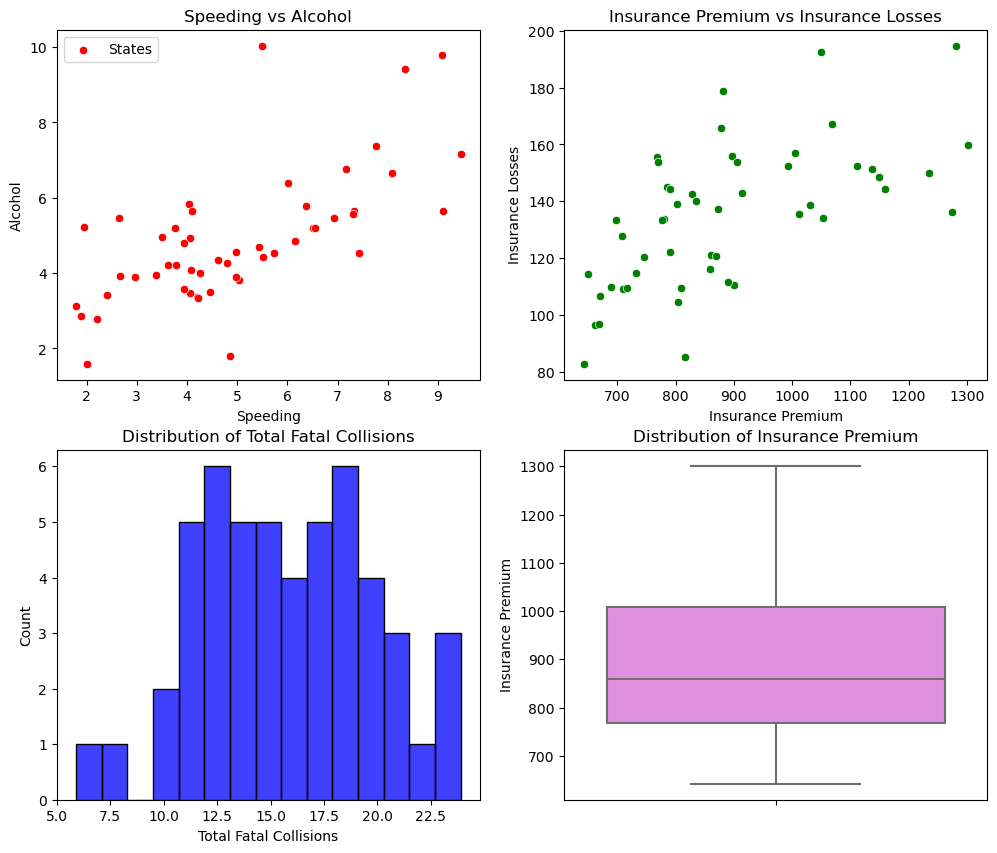

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(
    data = crashes,
    x = "speeding",
    y = "alcohol",
    color = "red",
    ax = axes[0, 0],
    label = "States"
)
axes[0, 0].set_title("Speeding vs Alcohol")
axes[0, 0].set_xlabel("Speeding")
axes[0, 0].set_ylabel("Alcohol")
axes[0, 0].legend()

sns.scatterplot(
    data = crashes,
    x = "ins_premium",
    y = "ins_losses",
    color = "green",
    ax = axes[0, 1]
)
axes[0, 1].set_title("Insurance Premium vs Insurance Losses")
axes[0, 1].set_xlabel("Insurance Premium")
axes[0, 1].set_ylabel("Insurance Losses")

sns.histplot(
    data = crashes,
    x = "total",
    bins = 15,
    color = "blue",
    ax = axes[1, 0]
)
axes[1, 0].set_title("Distribution of Total Fatal Collisions")
axes[1, 0].set_xlabel("Total Fatal Collisions")
axes[1, 0].set_ylabel("Count")

sns.boxplot(
    data = crashes,
    y = "ins_premium",
    ax = axes[1, 1],
    color = "violet",
)
axes[1, 1].set_title("Distribution of Insurance Premium")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Insurance Premium")

plt.show()

I chose these columns because they show different parts of the dataset clearly. The first scatterplot compares speeding and alcohol, and we can see that states with more speeding-related fatal collisions have more alcohol-related fatal collisions. The second scatterplot compares insurance premium and insurance losses, and it shows a roughly positive relationship between them. The histogram of total fatal collisions shows that most states are in the middle range, and there are two large peaks. The boxplot of insurance premium shows the overall spread of premium values, and it shows that the premiums vary a lot across states.